In [19]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
TRAIN_DIR = '/kaggle/input/datasets/msambare/fer2013/train'
TEST_DIR = '/kaggle/input/datasets/msambare/fer2013/test'

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
    horizontal_flip=True, validation_split=0.2
)

raw_train = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(48,48), 
    color_mode="grayscale", batch_size=64, class_mode="sparse", subset="training")

raw_val = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(48,48), 
    color_mode="grayscale", batch_size=64, class_mode="sparse", subset="validation")

def merge_gen(gen):
    for x, y in gen:
        y = np.where(y == 1, 0, y) # Disgust to Angry
        y = np.where(y > 1, y - 1, y) # Shift others (2-6 -> 1-5)
        yield x, y

train_gen = merge_gen(raw_train)
val_gen = merge_gen(raw_val)
print("Data ready for 6 classes!")

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Data ready for 6 classes!


In [21]:
from tensorflow.keras import layers, models

def build_moodmate_model():
    model = models.Sequential()
    
    #Input (48,48,1) -> Output (24,24,64)
    model.add(layers.Conv2D(64, (3,3), padding='same', input_shape=(48,48,1), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.25))
    
    # Output (12,12,128)
    model.add(layers.Conv2D(128, (5,5), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.25))
    
    # Output (6,6,512)
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.25))
    
    # Flatten & Dense Head
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(6, activation='softmax')) 
    
    return model

# Create and Compile
model = build_moodmate_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])


model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,241,542 (39.07 MB)

 Trainable params: 10,239,110 (39.06 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.2009 - loss: 2.4359
Epoch 1: val_accuracy improved from -inf to 0.23420, saving model to best_moodmate_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 68s 168ms/step - accuracy: 0.2009 - loss: 2.4353 - val_accuracy: 0.2342 - val_loss: 1.9053 - learning_rate: 0.0010
Epoch 2/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2347 - loss: 1.8743
Epoch 2: val_accuracy improved from 0.23420 to 0.26246, saving model to best_moodmate_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 64s 166ms/step - accuracy: 0.2347 - loss: 1.8741 - val_accuracy: 0.2625 - val_loss: 1.8128 - learning_rate: 0.0010
Epoch 3/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3036 - loss: 1.7058
Epoch 3: val_accuracy did not improve from 0.26246
358/358 ━━━━━━━━━━━━━━━━━━━━ 60s 167ms/step - accuracy: 0.3036 - loss: 1.7057 - val_accuracy: 0.1924 - val_loss: 2.0589 - learning_rate: 0.0010
Epoch 4/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accu

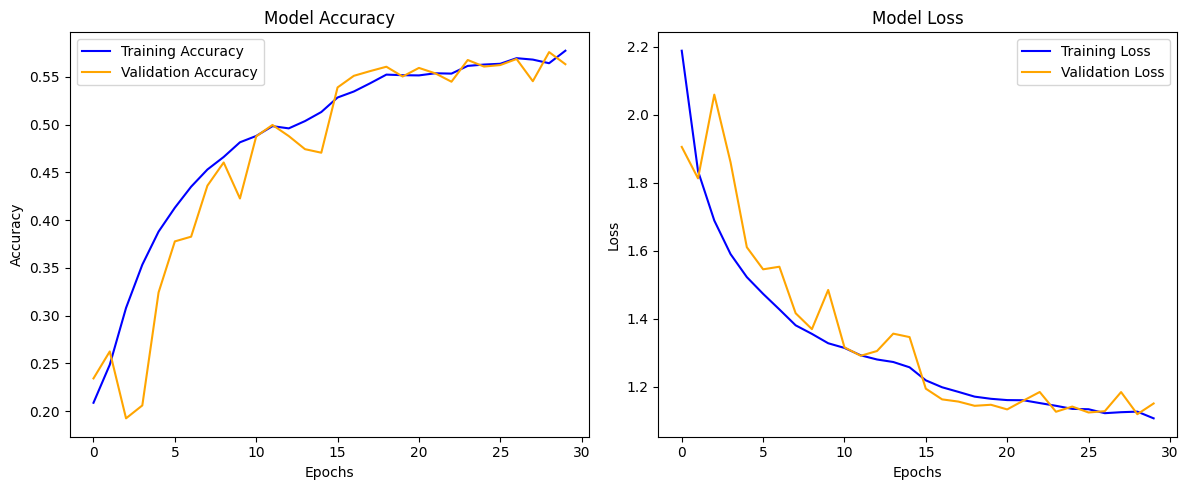

In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint


lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint("best_moodmate_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

# Start Training
history = model.fit(
    train_gen, 
    steps_per_epoch=raw_train.samples // 64,
    validation_data=val_gen, 
    validation_steps=raw_val.samples // 64,
    epochs=30, 
    callbacks=[lr_reducer, early_stop, checkpoint]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Create a clean, non-shuffled generator for evaluation

eval_val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(48, 48), color_mode="grayscale",
    batch_size=64, class_mode='sparse', subset='validation', shuffle=False
)

# 1. Get ordered probabilities
y_probs = model.predict(eval_val_gen)

# 2. Get true labels and apply the 6-class merge logic
y_true = eval_val_gen.classes.copy()
y_true = np.where(y_true == 1, 0, y_true)      # Merge Disgust -> Angry
y_true = np.where(y_true > 1, y_true - 1, y_true) # Shift 2-6 to 1-5
y_pred = np.argmax(y_probs, axis=1)

print("✅ Data Aligned. Ready for plotting.")

Found 5741 images belonging to 7 classes.
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step
✅ Data Aligned. Ready for plotting.


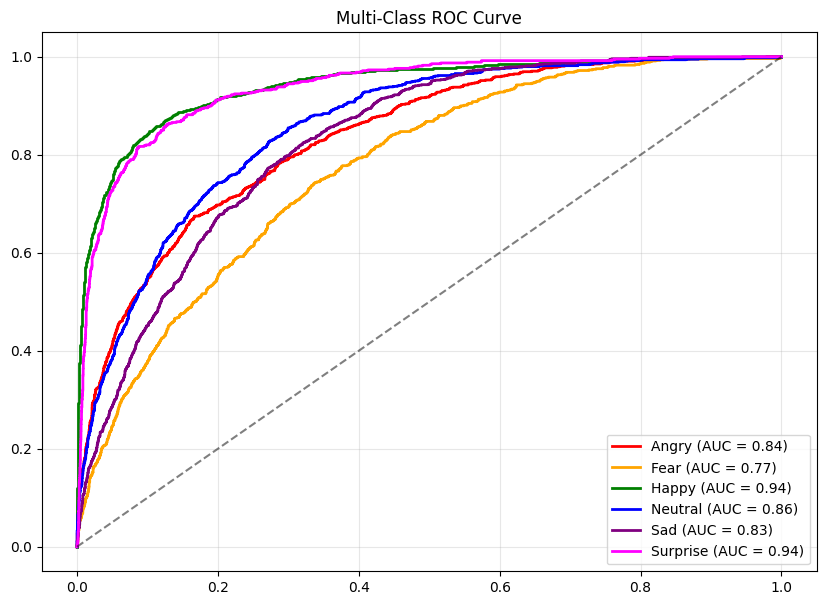

In [26]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

emotions = ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4, 5])

plt.figure(figsize=(10, 7))
colors = ['red', 'orange', 'green', 'blue', 'purple', 'magenta']

for i in range(6):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{emotions[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

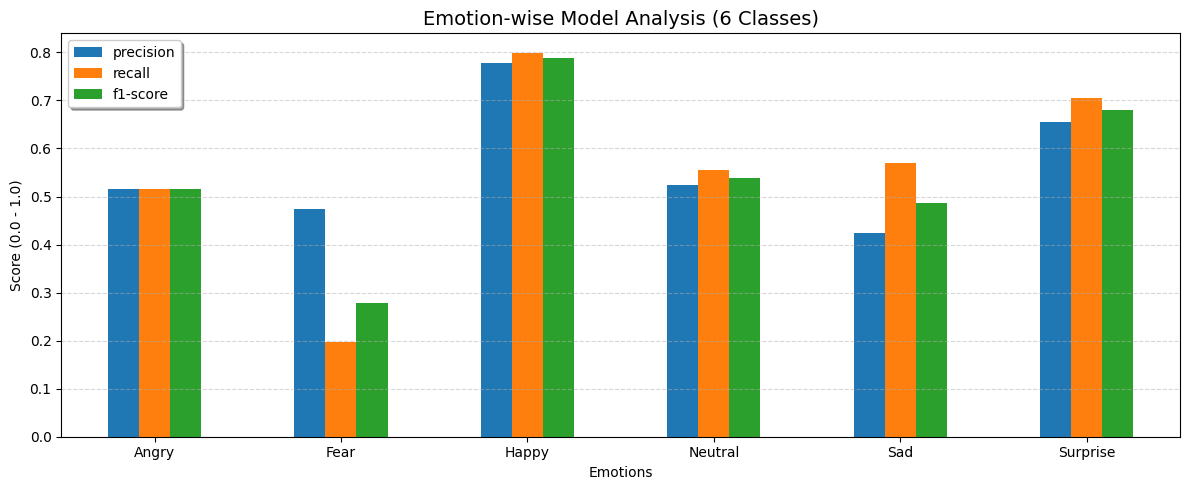

In [27]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the metrics table 
report = classification_report(y_true, y_pred, target_names=emotions, output_dict=True)
df_metrics = pd.DataFrame(report).iloc[:-1, :6].T 

# 2. Plot Precision, Recall, and F1
ax = df_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(12, 5))

plt.title('Emotion-wise Model Analysis (6 Classes)', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)')
plt.xlabel('Emotions')
plt.xticks(rotation=0)

# CHANGE: Moved the label box to the top left
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

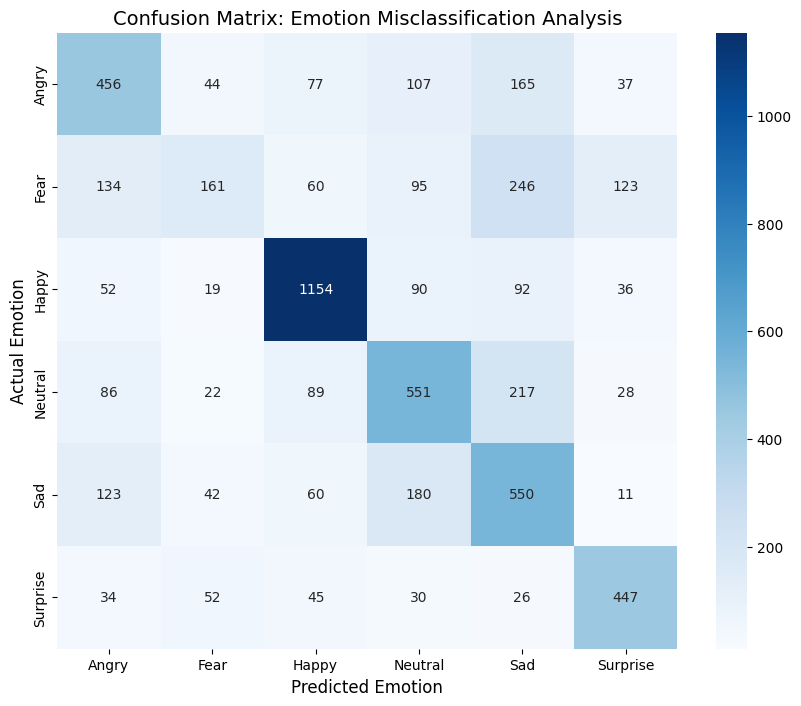

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Generate the Confusion Matrix using the aligned data from Cell 7
cm = confusion_matrix(y_true, y_pred)

# 2. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)

# 3. Formatting
plt.title('Confusion Matrix: Emotion Misclassification Analysis', fontsize=14)
plt.ylabel('Actual Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.show()

In [29]:

emotion_keywords = {
    'Angry':   ['hate', 'fire', 'anger', 'break', 'fight', 'mad'],
    'Fear':    ['dark', 'scared', 'alone', 'fear', 'ghost', 'run'],
    'Happy':   ['love', 'sun', 'happy', 'smile', 'joy', 'dance', 'party'],
    'Neutral': ['time', 'world', 'life', 'street', 'day', 'walk'],
    'Sad':     ['cry', 'blue', 'tears', 'gone', 'sorry', 'lonely', 'hurt'],
    'Surprise':['wow', 'magic', 'dream', 'light', 'wonder', 'star']
}

def get_recommendations(emotion, num_songs=5):
    # Get keywords for the detected emotion
    keywords = emotion_keywords.get(emotion, ['music'])
    
    # Create a search pattern (e.g., "love|sun|happy")
    pattern = '|'.join(keywords)
    
    # Search the 'text' column for matches
    # We use a sample of 15,000 songs to keep the search very fast
    subset = music_df.sample(n=15000)
    matches = subset[subset['text'].str.contains(pattern, case=False, na=False)]
    
    # Return top N results
    return matches[['song', 'artist']].head(num_songs)

print("Recommendation Engine Ready.")

Recommendation Engine Ready.


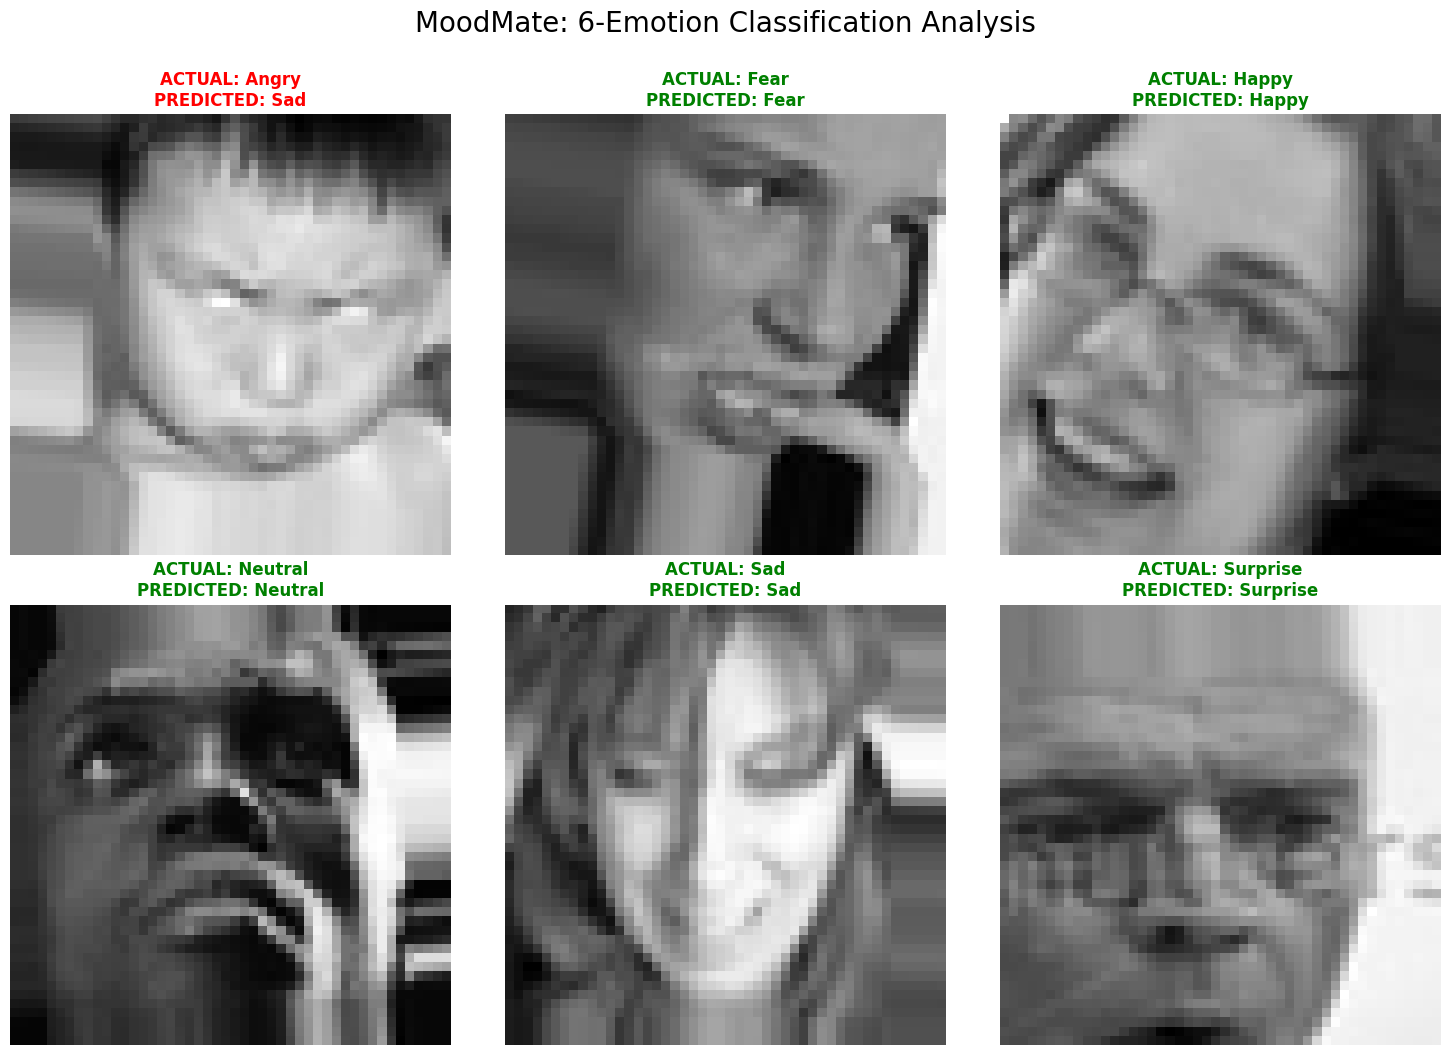

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare to collect one sample per emotion
emotions = ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
found_indices = {}
eval_val_gen.reset() # Using the non-shuffled generator from Cell 7

# Search for one index for each emotion
for i, label in enumerate(y_true):
    if label not in found_indices and len(found_indices) < 6:
        found_indices[label] = i

# 2. Plotting the 2x3 Grid
plt.figure(figsize=(15, 10))

for i, (emotion_idx, img_idx) in enumerate(sorted(found_indices.items())):
    # Get the image and preprocess
    img, _ = eval_val_gen[img_idx // 64] # Get the correct batch
    image = img[img_idx % 64]
    
    # Predict
    pred_probs = model.predict(np.expand_dims(image, axis=0), verbose=0)
    pred_idx = np.argmax(pred_probs)
    
    # Visuals
    plt.subplot(2, 3, i + 1)
    plt.imshow(image.reshape(48, 48), cmap='gray')
    
    # Color coding: Green if correct, Red if wrong
    color = 'green' if emotion_idx == pred_idx else 'red'
    
    title_text = f"ACTUAL: {emotions[int(emotion_idx)]}\nPREDICTED: {emotions[pred_idx]}"
    plt.title(title_text, color=color, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.suptitle("MoodMate: 6-Emotion Classification Analysis", fontsize=20, y=1.05)
plt.show()